# PPO, DPO and GRPO optimize one objective with three estimators

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## DPO solves for the reward instead

In [1]:
import numpy as np

rng = np.random.default_rng(0)
K, beta = 6, 0.5
r = np.array([1.0, 0.6, 0.3, 0.0, -0.4, 1.4])        # true reward per response
ref_logits = np.array([1.5, 1.0, 0.8, 0.5, 0.3, -1.0])
log_ref = ref_logits - np.log(np.exp(ref_logits).sum())

def softmax(z):
    e = np.exp(z - z.max()); return e / e.sum()

pi_star = softmax(log_ref + r / beta)                # closed-form optimum
kl = lambda p, q: (p * np.log(p / q)).sum()
print("pi_ref :", np.round(np.exp(log_ref), 3))
print("pi_*   :", np.round(pi_star, 3))

# Preference pairs from Bradley-Terry with the true reward
i, j = rng.integers(0, K, (2, 20000)); keep = i != j; i, j = i[keep], j[keep]
p_bt = 1 / (1 + np.exp(-(r[i] - r[j])))              # P(i beats j)
i_wins = rng.random(i.size) < p_bt
w, l = np.where(i_wins, i, j), np.where(i_wins, j, i)
H = -(p_bt * np.log(p_bt) + (1 - p_bt) * np.log1p(-p_bt)).mean()
print(f"pairs {i.size:,}, label entropy {H:.4f}")

theta = log_ref.copy()                               # start the policy at pi_ref
for step in range(1001):
    logp = theta - np.log(np.exp(theta).sum())
    m = beta * ((logp[w] - log_ref[w]) - (logp[l] - log_ref[l]))
    g = beta / (1 + np.exp(m))                       # -dLoss/dm = sigma(-m)
    grad = np.zeros(K)
    np.add.at(grad, w, -g); np.add.at(grad, l, g)
    theta -= 2.0 * grad / w.size
    if step in (0, 10, 50, 1000):
        print(f"step {step:4d}  loss {np.log1p(np.exp(-m)).mean():.4f}  "
              f"KL(pi_theta || pi_*) {kl(softmax(theta), pi_star):.5f}")
imp = beta * (theta - np.log(np.exp(theta).sum()) - log_ref)
print("implicit reward - mean:", np.round(imp - imp.mean(), 2))
print("true reward - mean    :", np.round(r - r.mean(), 2))

pi_ref : [0.35  0.212 0.174 0.129 0.106 0.029]
pi_*   : [0.608 0.166 0.074 0.03  0.011 0.111]
pairs 16,578, label entropy 0.6047
step    0  loss 0.6931  KL(pi_theta || pi_*) 0.35204
step   10  loss 0.6375  KL(pi_theta || pi_*) 0.12216
step   50  loss 0.6019  KL(pi_theta || pi_*) 0.00364


step 1000  loss 0.6003  KL(pi_theta || pi_*) 0.00058
implicit reward - mean: [ 0.53  0.15 -0.22 -0.51 -0.89  0.95]
true reward - mean    : [ 0.52  0.12 -0.18 -0.48 -0.88  0.92]


## GRPO uses the group as its baseline

In [2]:
# Policy-gradient estimators at pi = pi_ref, one prompt, G samples per group
pi, G, trials = np.exp(log_ref), 8, 50000
true_grad = pi * (r - pi @ r)                        # exact d E[r] / d logits
ys = rng.choice(K, size=(trials, G), p=pi)
score = np.eye(K)[ys] - pi                           # grad log pi(y), per sample

for offset in (0.0, 5.0):                            # shift every reward by a constant
    R = r[ys] + offset
    mu, sd = R.mean(1, keepdims=True), R.std(1, keepdims=True)
    loo = (R.sum(1, keepdims=True) - R) / (G - 1)    # leave-one-out mean (RLOO)
    advs = {"raw reward (no baseline)": R,
            "perfect critic V = E[r]": R - (pi @ r + offset),
            "RLOO, leave-one-out mean": R - loo,
            "GRPO, (r - mean) / std": (R - mu) / (sd + 1e-8)}
    print(f"reward offset {offset}")
    for name, A in advs.items():
        est = (A[..., None] * score).mean(1)         # one gradient per group
        mean = est.mean(0)
        scale = mean @ true_grad / (true_grad @ true_grad)
        noise = ((est - mean) ** 2).sum(1).mean() / (mean @ mean)
        print(f"  {name:26s} scale {scale:5.2f}  relative variance {noise:6.2f}")
print(f"sigma of r under pi: {np.sqrt(pi @ (r - pi @ r) ** 2):.3f}, "
      f"groups with sigma_G = 0: {(sd == 0).mean():.3%}")
u = np.array([0.8, 1.2])                             # PPO clip edges, eps = 0.2
print(f"KL bound, max of u - 1 - ln u on [0.8, 1.2]: {np.max(u - 1 - np.log(u)):.4f}")

reward offset 0.0
  raw reward (no baseline)   scale  1.00  relative variance   0.85
  perfect critic V = E[r]    scale  1.00  relative variance   0.45
  RLOO, leave-one-out mean   scale  1.00  relative variance   0.54
  GRPO, (r - mean) / std     scale  1.93  relative variance   0.53


reward offset 5.0
  raw reward (no baseline)   scale  1.01  relative variance  64.46
  perfect critic V = E[r]    scale  1.00  relative variance   0.45


  RLOO, leave-one-out mean   scale  1.00  relative variance   0.54
  GRPO, (r - mean) / std     scale  1.93  relative variance   0.53
sigma of r under pi: 0.487, groups with sigma_G = 0: 0.018%
KL bound, max of u - 1 - ln u on [0.8, 1.2]: 0.0231


## The figure

In [3]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

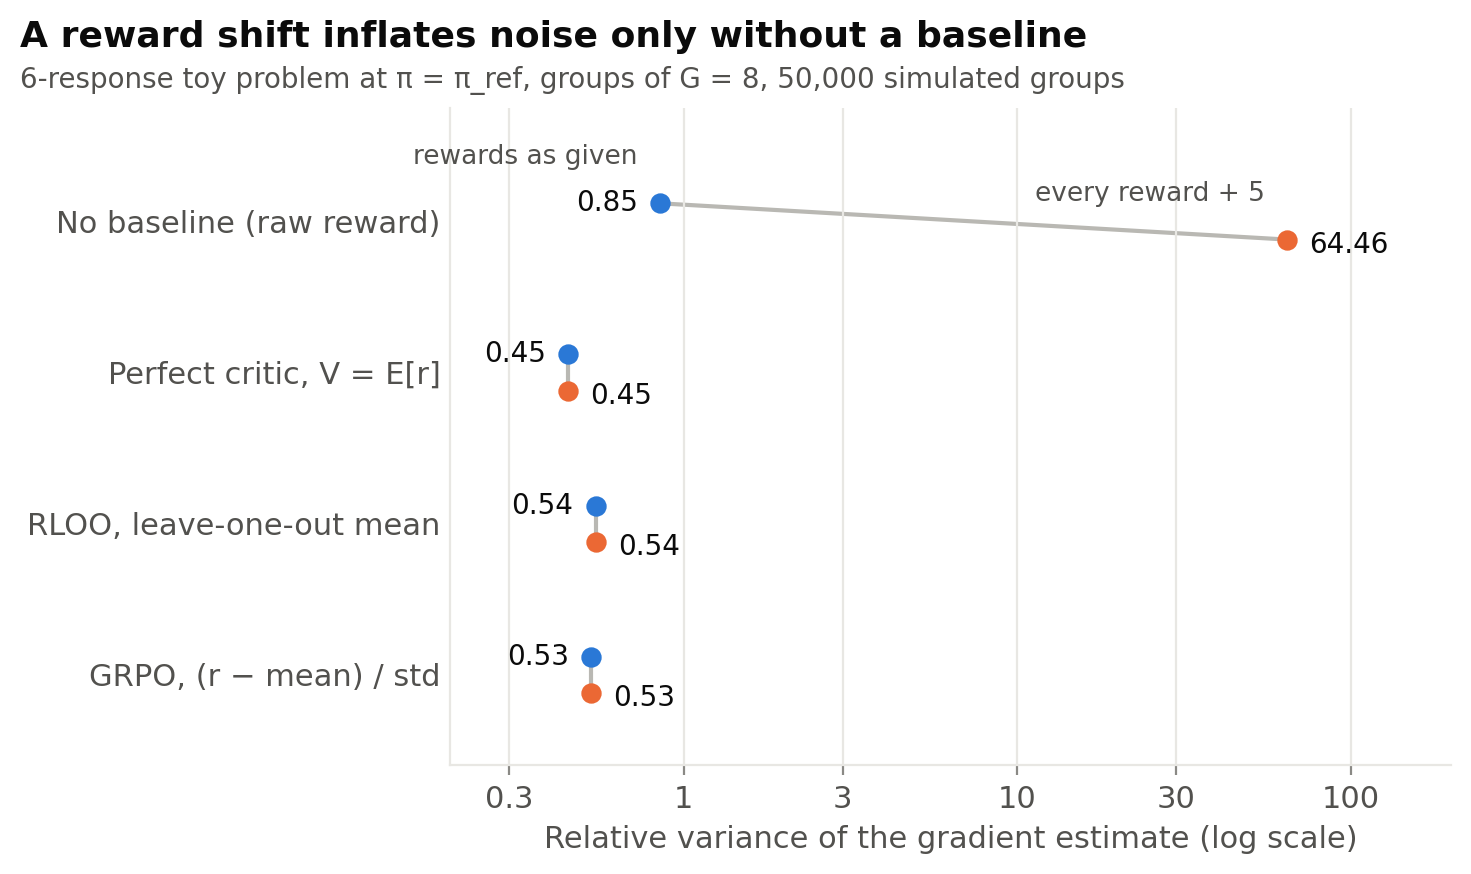

In [4]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
ARTICLE_MD = '```python\nimport numpy as np\n\nrng = np.random.default_rng(0)\nK, beta = 6, 0.5\nr = np.array([1.0, 0.6, 0.3, 0.0, -0.4, 1.4])        # true reward per response\nref_logits = np.array([1.5, 1.0, 0.8, 0.5, 0.3, -1.0])\nlog_ref = ref_logits - np.log(np.exp(ref_logits).sum())\n\ndef softmax(z):\n    e = np.exp(z - z.max()); return e / e.sum()\n\npi_star = softmax(log_ref + r / beta)                # closed-form optimum\nkl = lambda p, q: (p * np.log(p / q)).sum()\nprint("pi_ref :", np.round(np.exp(log_ref), 3))\nprint("pi_*   :", np.round(pi_star, 3))\n\n# Preference pairs from Bradley-Terry with the true reward\ni, j = rng.integers(0, K, (2, 20000)); keep = i != j; i, j = i[keep], j[keep]\np_bt = 1 / (1 + np.exp(-(r[i] - r[j])))              # P(i beats j)\ni_wins = rng.random(i.size) < p_bt\nw, l = np.where(i_wins, i, j), np.where(i_wins, j, i)\nH = -(p_bt * np.log(p_bt) + (1 - p_bt) * np.log1p(-p_bt)).mean()\nprint(f"pairs {i.size:,}, label entropy {H:.4f}")\n\ntheta = log_ref.copy()                               # start the policy at pi_ref\nfor step in range(1001):\n    logp = theta - np.log(np.exp(theta).sum())\n    m = beta * ((logp[w] - log_ref[w]) - (logp[l] - log_ref[l]))\n    g = beta / (1 + np.exp(m))                       # -dLoss/dm = sigma(-m)\n    grad = np.zeros(K)\n    np.add.at(grad, w, -g); np.add.at(grad, l, g)\n    theta -= 2.0 * grad / w.size\n    if step in (0, 10, 50, 1000):\n        print(f"step {step:4d}  loss {np.log1p(np.exp(-m)).mean():.4f}  "\n              f"KL(pi_theta || pi_*) {kl(softmax(theta), pi_star):.5f}")\nimp = beta * (theta - np.log(np.exp(theta).sum()) - log_ref)\nprint("implicit reward - mean:", np.round(imp - imp.mean(), 2))\nprint("true reward - mean    :", np.round(r - r.mean(), 2))\n```\n```python\n# Policy-gradient estimators at pi = pi_ref, one prompt, G samples per group\npi, G, trials = np.exp(log_ref), 8, 50000\ntrue_grad = pi * (r - pi @ r)                        # exact d E[r] / d logits\nys = rng.choice(K, size=(trials, G), p=pi)\nscore = np.eye(K)[ys] - pi                           # grad log pi(y), per sample\n\nfor offset in (0.0, 5.0):                            # shift every reward by a constant\n    R = r[ys] + offset\n    mu, sd = R.mean(1, keepdims=True), R.std(1, keepdims=True)\n    loo = (R.sum(1, keepdims=True) - R) / (G - 1)    # leave-one-out mean (RLOO)\n    advs = {"raw reward (no baseline)": R,\n            "perfect critic V = E[r]": R - (pi @ r + offset),\n            "RLOO, leave-one-out mean": R - loo,\n            "GRPO, (r - mean) / std": (R - mu) / (sd + 1e-8)}\n    print(f"reward offset {offset}")\n    for name, A in advs.items():\n        est = (A[..., None] * score).mean(1)         # one gradient per group\n        mean = est.mean(0)\n        scale = mean @ true_grad / (true_grad @ true_grad)\n        noise = ((est - mean) ** 2).sum(1).mean() / (mean @ mean)\n        print(f"  {name:26s} scale {scale:5.2f}  relative variance {noise:6.2f}")\nprint(f"sigma of r under pi: {np.sqrt(pi @ (r - pi @ r) ** 2):.3f}, "\n      f"groups with sigma_G = 0: {(sd == 0).mean():.3%}")\nu = np.array([0.8, 1.2])                             # PPO clip edges, eps = 0.2\nprint(f"KL bound, max of u - 1 - ln u on [0.8, 1.2]: {np.max(u - 1 - np.log(u)):.4f}")\n```'
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib
    import contextlib, io, re
    import numpy as np

    # Run the article's first block (toy problem, DPO fit) so the RNG state matches,
    # then repeat its second block, keeping the relative variances.
    here = pathlib.Path(__file__).parent
    md = ARTICLE_MD
    ns = {}
    with contextlib.redirect_stdout(io.StringIO()):
        exec(re.findall(r"```python\n(.*?)```", md, flags=re.S)[0], ns)
    rng, K, r, log_ref = ns["rng"], ns["K"], ns["r"], ns["log_ref"]

    pi, G, trials = np.exp(log_ref), 8, 50000
    true_grad = pi * (r - pi @ r)
    ys = rng.choice(K, size=(trials, G), p=pi)
    score = np.eye(K)[ys] - pi
    names = ["No baseline (raw reward)", "Perfect critic, V = E[r]",
             "RLOO, leave-one-out mean", "GRPO, (r − mean) / std"]
    rv = {}
    for offset in (0.0, 5.0):
        R = r[ys] + offset
        mu, sd = R.mean(1, keepdims=True), R.std(1, keepdims=True)
        loo = (R.sum(1, keepdims=True) - R) / (G - 1)
        advs = [R, R - (pi @ r + offset), R - loo, (R - mu) / (sd + 1e-8)]
        out = []
        for A in advs:
            est = (A[..., None] * score).mean(1)
            mean = est.mean(0)
            out.append(((est - mean) ** 2).sum(1).mean() / (mean @ mean))
        rv[offset] = out
    print({k: [round(v, 2) for v in vals] for k, vals in rv.items()})

    f, ax = fig()
    ax.set_xscale("log")
    y = np.arange(len(names))[::-1]
    for yi, a, b in zip(y, rv[0.0], rv[5.0]):
        ax.plot([a, b], [yi + 0.12, yi - 0.12], color=NEUTRAL, lw=1.5, zorder=1)
    ax.scatter(rv[0.0], y + 0.12, color=S1, s=40, zorder=3)
    ax.scatter(rv[5.0], y - 0.12, color=S2, s=40, zorder=3)
    for yi, a, b in zip(y, rv[0.0], rv[5.0]):
        ax.annotate(f"{a:.2f}", (a, yi + 0.12), xytext=(-8, 0), textcoords="offset points",
                    ha="right", va="center", color=INK, fontsize=10)
        ax.annotate(f"{b:.2f}", (b, yi - 0.12), xytext=(8, -2), textcoords="offset points",
                    ha="left", va="center", color=INK, fontsize=10)
    # direct series labels on the top row
    ax.annotate("rewards as given", (rv[0.0][0], y[0] + 0.12), xytext=(-8, 14),
                textcoords="offset points", ha="right", color=INK_2, fontsize=9.5)
    ax.annotate("every reward + 5", (rv[5.0][0], y[0] - 0.12), xytext=(-8, 14),
                textcoords="offset points", ha="right", color=INK_2, fontsize=9.5)
    ax.set_yticks(y, names)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0.2, 200); ax.set_ylim(-0.6, 3.75)
    ax.set_xticks([0.3, 1, 3, 10, 30, 100], ["0.3", "1", "3", "10", "30", "100"])
    ax.set_xticks([], minor=True)
    ax.set_xlabel("Relative variance of the gradient estimate (log scale)")
    TX = -0.43                                          # align title with y labels
    ax.set_title("A reward shift inflates noise only without a baseline", x=TX, ha="left")
    ax.text(TX, 1.02, "6-response toy problem at π = π_ref, groups of G = 8, 50,000 simulated groups",
            transform=ax.transAxes, color=INK_2, fontsize=10, va="bottom", ha="left")
    path = here / "08-estimator-variance.png"
    save(f, path)
import matplotlib.pyplot as plt
plt.show()